# Laboratorium 4 - rekomendacje dla portali informacyjnych

## Przygotowanie

 * pobierz i wypakuj dataset: https://mind201910small.blob.core.windows.net/release/MINDsmall_train.zip
   * więcej możesz poczytać tutaj: https://learn.microsoft.com/en-us/azure/open-datasets/dataset-microsoft-news
 * [opcjonalnie] Utwórz wirtualne środowisko
 `python3 -m venv ./recsyslab4`
 * zainstaluj potrzebne biblioteki:
 `pip install nltk sklearn`

## Część 1. - przygotowanie danych

In [1]:
# importujemy wszystkie potrzebne pakiety

import codecs
from collections import defaultdict # mozesz uzyc zamiast zwyklego slownika, rozwaz wplyw na czas obliczen
import math
import re
from string import punctuation

import nltk
nltk.download('stopwords')
nltk.download('punkt_tab')

from nltk.corpus import stopwords
from nltk.stem import RSLPStemmer
from nltk.stem import WordNetLemmatizer
from nltk.stem.lancaster import LancasterStemmer
from nltk.stem.porter import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

# mozesz uzyc do obliczania najbardziej podobnych tekstow zamiast liczenia "na piechote"
# ale pamietaj o dostosowaniu formatu danych
from sklearn.neighbors import NearestNeighbors

# na potrzeby wizualizacji
import matplotlib.pyplot as plt
from wordcloud import WordCloud

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/maciejmakowski/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/maciejmakowski/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# definiujemy potrzebne zmienne

PATH = './MINDsmall_train'
STOPWORDS = set(stopwords.words('english'))

In [3]:
# wczytujemy metadane artykulow

def parse_news_entry(entry):
    news_id, category, subcategory, title, abstract = entry.split('\t')[:5]
    return {
        'news_id': news_id,
        'category': category,
        'subcategory': subcategory,
        'title': title,
        'abstract': abstract
    }

def get_news_metadata():
    with codecs.open(f'{PATH}/news.tsv', 'r', 'UTF-8') as f:
        raw = [x for x in f.read().split('\n') if x]
        parsed_entries = [parse_news_entry(entry) for entry in raw]
        return {x['news_id']: x for x in parsed_entries}

news = get_news_metadata()
news_ids = sorted(list(news.keys()))
news_indices = {x[1]: x[0] for x in enumerate(news_ids)}
print(len(news))

51282


In [4]:
def parse_history_entry(entry):
    _id, user_id, _time, history, _impressions = entry.split('\t')
    history = [x for x in history.split() if x]
    return user_id, history

def get_users_history():
    with codecs.open(f'{PATH}/behaviors.tsv', 'r', 'UTF-8') as f:
        lines = [x for x in f.read().split('\n') if x]
        entries = [parse_history_entry(x) for x in lines]
        return dict(entries)

users_history = get_users_history()
test_users = 'U53231', 'U89744', 'U10045', 'U92486', 'U70879'
print(len(users_history))

50000


## Część 2. - TF-IDF

In [5]:
# normalizujemy teksty na potrzeby dalszego przetwarzania

def preprocess_text(text):
    # zamieniamy wszystkie ciagi bialych znakow na pojedyncze spacje
    text = re.sub(r'\s+', ' ', text)
    # usuwamy znaki interpunkcyjne
    text = re.sub(f'[{punctuation}]', '', text)
    # usuwamy wszystkie liczby
    text = re.sub(r'\d+', '', text)
    # podmieniamy wszystkie wielkie litery
    text = text.lower()
    # dzielimy na tokeny
    tokens = text.split()
    # usuwamy stopwords
    tokens = [token for token in tokens if token not in STOPWORDS]
    return tokens

def stem_texts(corpus):
    stemmer = PorterStemmer()  # przetestuj rozne stemmery
    return [[stemmer.stem(word) for word in preprocess_text(text)] for text in corpus]

texts = [news[news_id]['abstract'] for news_id in news_ids]
stemmed_texts = stem_texts(texts)

In [6]:
# porownajmy teksty przed i po przetworzeniu

print(texts[2] + '\n')
print(' '.join(stemmed_texts[2]))

"I think we have a really good team, and a team that can really do some special, good things because that group is very close in there." - Brian Schmetzer

think realli good team team realli special good thing group close brian schmetzer


In [7]:
# tworzymy liste wszystkich slow w korpusie

def get_all_words_sorted(corpus):
    # generujemy posortowana alfabetycznie liste wszystkich slow (tokenow)
    return sorted(list(set([word for text in corpus for word in text])))

wordlist = get_all_words_sorted(stemmed_texts)
word_indices = {x[1]: x[0] for x in enumerate(wordlist)}
print(len(wordlist))

41886


In [9]:
# obliczamy liczbe tekstow, w ktorych wystapilo kazde ze slow
# pamietaj, ze jesli slowo wystapilo w danym tekscie wielokrotnie, to liczymy je tylko raz

def get_document_frequencies(corpus, wordlist):
    word_frequency_dict = defaultdict(lambda: 0)
    for text in corpus:
        unique_words = set()
        for word in text:
            if word not in unique_words:
                word_frequency_dict[word] += 1
                unique_words.add(word)
    return dict(word_frequency_dict)

document_frequency = get_document_frequencies(stemmed_texts, wordlist)

In [10]:
# obliczamy liczbe wystapien kazdego slowa w kazdym tekscie

def get_term_frequencies(corpus, news_indices):
    return {news_id: {word: text.count(word) for word in text} for news_id, text in zip(news_indices, corpus)}

term_frequency = get_term_frequencies(stemmed_texts, news_indices)

In [46]:
# sprawdzmy wyniki

term_frequency[news_ids[2]]

{'think': 1,
 'realli': 2,
 'good': 2,
 'team': 2,
 'special': 1,
 'thing': 1,
 'group': 1,
 'close': 1,
 'brian': 1,
 'schmetzer': 1}

In [47]:
# obliczamy metryke tf_idf

def calculate_tf_idf(term_frequency, document_frequency, corpus_size):
    # return {news_id -> {word -> tf_idf}}
    results = {news_id: defaultdict(lambda: 0) for news_id in term_frequency.keys()}
    for news_id, words_count in term_frequency.items():
        for word, count in words_count.items():
            results[news_id][word] = count * math.log(corpus_size / (1 + document_frequency.get(word, 0)))

    return results

tf_idf = calculate_tf_idf(term_frequency, document_frequency, len(news_ids))

In [48]:
# sprawdzmy wyniki

tf_idf[news_ids[2]]

defaultdict(<function __main__.calculate_tf_idf.<locals>.<lambda>()>,
            {'think': 4.358934303449984,
             'realli': 9.702267330175008,
             'good': 8.08317966957147,
             'team': 6.15650911061712,
             'special': 4.762876182017627,
             'thing': 4.110503432421125,
             'group': 4.260303700008357,
             'close': 3.9234369082429446,
             'brian': 5.619348418680872,
             'schmetzer': 9.235657179959972})

## Część 3. - Podobieństwo tekstów

In [73]:
# obliczmy odleglosc miedzy dwoma artykulami
# przetestuj rozne metryki odleglosci i wybierz najlepsza

def calculate_distance(tf_idf, id1, id2, metric='cosine'):
    v1, v2 = tf_idf[id1], tf_idf[id2]
    all_words = set(v1.keys()) | set(v2.keys())
    
    if metric == 'cosine':
        dot_product = sum(v1.get(w, 0) * v2.get(w, 0) for w in all_words)
        norm1 = math.sqrt(sum(v1.get(w, 0) ** 2 for w in all_words))
        norm2 = math.sqrt(sum(v2.get(w, 0) ** 2 for w in all_words))
        return 1 - (dot_product / (norm1 * norm2) if norm1 * norm2 > 0 else 0)
    else:  # euclidean
        return math.sqrt(sum((v1.get(w, 0) - v2.get(w, 0)) ** 2 for w in all_words))

# Wersja pomocnicza do porównywania dwóch wektorów bezpośrednio
def calculate_distance_vectors(v1, v2, metric='cosine'):
    all_words = set(v1.keys()) | set(v2.keys())
    
    if metric == 'cosine':
        dot_product = sum(v1.get(w, 0) * v2.get(w, 0) for w in all_words)
        norm1 = math.sqrt(sum(v1.get(w, 0) ** 2 for w in all_words))
        norm2 = math.sqrt(sum(v2.get(w, 0) ** 2 for w in all_words))
        return 1 - (dot_product / (norm1 * norm2) if norm1 * norm2 > 0 else 0)
    else:  # euclidean
        return math.sqrt(sum((v1.get(w, 0) - v2.get(w, 0)) ** 2 for w in all_words))

calculate_distance(tf_idf, news_ids[2], news_ids[1])

0.9748528016831882

In [74]:
# funkcja pomocnicza do wyswietlania artykulow
def print_news_entry(n_id, corpus):
    print(f'id: {n_id}\n\ttitle: {corpus[n_id]["title"]}\n\ttext: {corpus[n_id]["abstract"]}')

print_news_entry('N42782', news)

id: N42782
	title: Three takeaways from Yankees' ALCS Game 5 victory over the Astros
	text: The Yankees kept hope alive thanks to some impressive starting pitching and a pair of early home runs.


In [75]:
# wyznaczmy k najpodobniejszych tekstow do danego
# pamietaj o odpowiedniej kolejnosci sortowania w zaleznosci od wykorzystanej metryki
# pamietaj, zeby wsrod podobnych tekstow nie bylo danego

def get_k_most_similar_news(tf_idf, n_id, k):
    distances = [(calculate_distance(tf_idf, n_id, n_id2, 'cosine'), n_id2) for n_id2 in news_ids if n_id != n_id2]
    distances.sort(key=lambda x: x[0], reverse=False)
    return [x[1] for x in distances[:k]]

def print_k_most_similar_news(tf_idf, n_id, k, corpus):
    similar = get_k_most_similar_news(tf_idf, n_id, k)
    print_news_entry(n_id, corpus)
    print(f'\n{k} most similar:')
    for s_id in similar:
       print_news_entry(s_id, corpus)
       print(calculate_distance(tf_idf, n_id, s_id, 'cosine'))

print_k_most_similar_news(tf_idf, news_ids[42337], 5, news)

id: N58544
	title: Tiny Electric Car Cost $420,000 To Build
	text: A MAN claims he has created a car that might solve the world's traffic congestion problems. Rick Woodbury from Spokane, Washington USA, is the president, founder and sole employee of 'Commuter Cars.' The carmaker's flagship model is the 2005 super slim two-seater Tango T600, a high-performance electric car that preceded Tesla. Rick told BTV: "I started this company 21 years ago   it was based on an idea that I came up with in 1982." He was inspired by the shocking traffic congestion he had to face on a daily basis. "I used to drive a Porsche from Beverly Hills to Hermosa Beach every day and the traffic was horrendous," explained Rick. What really made Rick think about a solution was the fact that in most of the cars he would see in his commute were occupied by lone drivers. "I noticed that everybody around me was a single occupant in a car, taking up the whole lane," Rick said. Living and working in Los Angeles also hel

## Część 4. - Profile użytkowników

In [76]:
# oblicz srednia z wektorow tf-idf artykulow o zadanych id-kach
def calculate_average_vector(tf_idf, news_ids: list[str]) -> dict[str, float]:
    avg_vector = defaultdict(lambda: 0)
    for n_id in news_ids:
        for word, value in tf_idf[n_id].items():
            avg_vector[word] += value
    num_articles = len(news_ids)
    for word in avg_vector:
        avg_vector[word] /= num_articles
    return dict(avg_vector)

# wykorzystaj powyzsza funkcje, by policzyc wektor kazdego uzytkownika
def calculate_users_vectors(tf_idf, users_history) -> dict[str, list]:
    return {user_id: calculate_average_vector(tf_idf, history) for user_id, history in users_history.items()}


user_vectors = calculate_users_vectors(tf_idf, users_history)


In [77]:
# sprawdz wyliczony profil dla przykladowego uzytkownika
print(sorted([(k,v) for k,v in user_vectors[test_users[0]].items() if v], key=lambda x: -x[1]))

[('fire', 1.267870955689801), ('plane', 1.1691478634094798), ('ditch', 1.0455335096825589), ('diaz', 0.9821147398345644), ('land', 0.8865289474988164), ('paula', 0.8170949215206292), ('acr', 0.8082441837933311), ('ventura', 0.7750904121160552), ('mcconnel', 0.7667373898157289), ('flight', 0.7521950380582644), ('maria', 0.7386269329084978), ('aircraft', 0.7180671820717007), ('hailston', 0.696177343123283), ('storm', 0.6908974152787826), ('chaser', 0.6596897985685695), ('tornado', 0.6372059241903388), ('noaa', 0.6177050367898467), ('airlin', 0.6110819502740801), ('twoweek', 0.6101792856714304), ('story', 0.6003587225715462), ('contain', 0.5975610999997227), ('california', 0.5952504253913916), ('santa', 0.5729921643322362), ('may', 0.5471829630169326), ('accord', 0.5430078051546358), ('report', 0.5347503413433808), ('ef', 0.5341285187434), ('larg', 0.5298426148726694), ('tanker', 0.529364849136352), ('alleg', 0.5255275542507473), ('mandatori', 0.52069621649319), ('behind', 0.5069370977744

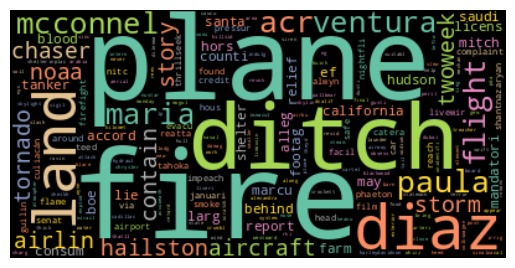

In [78]:
# skorzystajmy ze znanej juz biblioteki, by to lepiej zwizualizowac
def plot_vector(tf_idf_vector):
    wordcloud = WordCloud(random_state=42, background_color='black', colormap='Set2')
    wordcloud.generate_from_frequencies(frequencies=tf_idf_vector)
    plt.figure()
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.show()

plot_vector(user_vectors[test_users[0]])

## Część 5. - Rekomendacje dla użytkowników

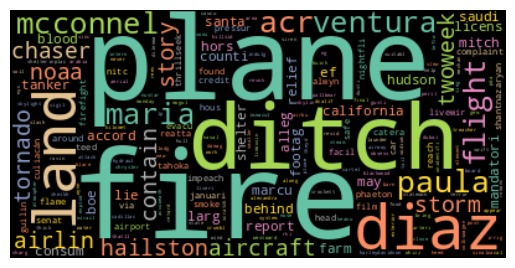

id: N58169
	title: Helicopter crews take on California's Maria fire with nighttime flights
	text: Ventura County Fire crews battling the Maria Fire in California used nighttime helicopter flights to control the blaze, according to local authorities. "Helicopters that fight fire at night are not common. They take special knowledge, skills, training and technology," Ventura County Fire wrote on Twitter. The Maria Fire broke out in the hills above Santa Paula and began to spread on Thursday evening, October 31. By the evening of November 3, authorities said, the fire has grown to 9,412 acres but was 70 percent contained. Only two structures were destroyed by the fire, but widespread evacuation orders were in place. The Ventura County Sheriff said that 1,800 structures were threatened as the fire grew on October 31 and that 7,500 people were under evacuation orders. Credit: Ventura County Fire via Storyful
id: N58561
	title: Wildfire Alert Cameras Captures Ignition and Spread of Maria Fire

In [79]:
# wykorzystujac wektory tresci i profile uzytkownikow,
#   wygeneruj liste k artykulow najlepiej dopasowanych do uzytkownika
#   pamietaj o odsianiu artykulow, ktore uzytkownik juz kliknal

def recommend(tf_idf, user_id, news, users_history, k):
    user_vector = user_vectors[user_id]
    read_news_ids = set(users_history[user_id])
    not_read_news_ids = [n_id for n_id in news.keys() if n_id not in read_news_ids]

    distances = [(calculate_distance_vectors(user_vector, tf_idf[n_id]), n_id) for n_id in not_read_news_ids]
    distances.sort(key=lambda x: x[0])
    return [n_id for _, n_id in distances[:k]]

# dla wybranego uzytkownika, korzystajac z juz zaimplementowanych funkcji,
#   pokaz jego historie, profil (wordcloud) i rekomendacje

user = test_users[0]
plot_vector(user_vectors[user])

recommended_news = recommend(tf_idf, user, news, users_history, 5)
for n_id in recommended_news:
    print_news_entry(n_id, news)

## Część 6. - Ocena jakości

In [80]:
# jaccard index to metryka podobienstwa zbiorow, lekko ja zmodyfikujemy
# przeciecie wektorow to minimum po kazdej wspolrzednej
# unia wektorow to maksimum po kazdej wspolrzednej
# jaccard index to iloraz sum tych dwoch wartosci

def jaccard(v1, v2):
    intersection = sum(min(v1.get(w, 0), v2.get(w, 0)) for w in set(v1.keys()) | set(v2.keys()))
    union = sum(max(v1.get(w, 0), v2.get(w, 0)) for w in set(v1.keys()) | set(v2.keys()))
    return intersection / union if union > 0 else 0


In [82]:
# dla kazdego uzytkownika wygeneruj k-elementowa rekomendacje
# policz jaccard index miedzy wektorem uzytkownika a srednim wektorem elementow z rekomendacji
# porownaj wyniki dla dwoch roznych k i dwoch roznych metryk podobienstwa

results = []
for user in test_users:
    for k in [5, 10]:
        recommended_news = recommend(tf_idf, user, news, users_history, k)
        recommended_vector = calculate_average_vector(tf_idf, recommended_news)
        jaccard_index = jaccard(user_vectors[user], recommended_vector)
        results.append((user, k, jaccard_index))

for user, k, jaccard_index in results:
    print(f'User: {user}, k={k}, Jaccard index: {jaccard_index}')

User: U53231, k=5, Jaccard index: 0.05366953336012765
User: U53231, k=10, Jaccard index: 0.07826476902476417
User: U89744, k=5, Jaccard index: 0.03870460740839487
User: U89744, k=10, Jaccard index: 0.05302710677576677
User: U10045, k=5, Jaccard index: 0.0529495914990602
User: U10045, k=10, Jaccard index: 0.06309164556879956
User: U92486, k=5, Jaccard index: 0.04559847297319376
User: U92486, k=10, Jaccard index: 0.058208333835581015
User: U70879, k=5, Jaccard index: 0.038992878752275674
User: U70879, k=10, Jaccard index: 0.05406713978036029
